---
title: "Lecture 15: Numerical integration"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture15_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Numerical integration

When learning integration, we typically learn to look for an antiderivative and use evaluation of this function to calculate integrals.  However, we often learn that this is a limit of a *quadrature* technique -- Riemann sums.  *Quadrature* or *numerical integration* samples values of the function at node points and approximates the integral using these values.  

. . .

Numerical integration is available to us even when useful antiderivatives are not.

## Example


In [4]:
# | echo: false
using Pkg; Pkg.add("QuadGK")
using QuadGK

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [5]:
# the antiderivative of exp(x) is itself so evaluating the integral on [0,1] is trivial
exact = exp(1) - 1

1.718281828459045

In [8]:
# numerical integration is just as exact in this case
Q, errest = quadgk(x->exp(x),0,1)
@show Q;

Q = 1.7182818284590453


In [9]:
# numerical integration is available even without an antiderivative
Q, errest = quadgk(x->exp(sin(x)),0,1)
@show Q;

Q = 1.6318696084180515


## Numerical integration

*Numerical integration* combines values of the integrand sampled at nodes.  

. . .

For now, we will assume *equally spaced nodes*: $$t_i = a + ih, \quad\quad h = \frac{b-a}{n}, \quad\quad i=0, \cdots, n.$$

. . .

::: {.callout-note icon=false}
## Definition: Numerical integration formula
A **numerical integration** formula is a list of **weights** $w_0, \cdots, w_n$ chosen so that for all $f$ in some class of functions, $$\int_a^b f(x) dx \approx h \sum_{i=0}^n w_i f(t_i),$$ with the $t_i$ defined above.  The weights are independent of $f$ and $h$.
:::

. . .

Note that numerical integration can be used even when the integrand $f$ is not known explicitly (e.g., if the values are given as data).  We'll assume here that $f$ is known though.

## Trapezoid formula

A straightforward quadrature approach is to mimic finite-differences -- interpolate the data and operate on it exactly.

. . .

One of the most important formulas results from integration of the piecewise linear interpolant.  Using the cardinal basis form of the interpolant (using *hat* functions), we have $$\int_a^b f(x) dx \approx \int_a^b \sum_{i=0}^n f(t_i) H_i(x) dx = \sum_{i=0}^n f(t_i) \int_a^b H_i(x) dx.$$

. . .

Thus, the weights should be $w_i = \frac1h \int_a^b H_i(x) dx$ and using the integrals of the hat functions (areas of triangles), we have $$w_i = 
\begin{cases}1 & i = 1, \cdots, n-1 \\ \frac12 & i = 0, n.\end{cases}$$

---

::: {.callout-note icon=false}
## Definition: Trapezoid formula
The **trapezoid formula** is a numerical integration formula with $$w_i = \begin{cases}1 & i = 1, \cdots, n-1 \\ \frac12 & i = 0, n.\end{cases}$$
:::

In [10]:
"""
    trapezoid(f,a,b,n)
    
Apply the trapezoid integration formula for integrand 'f' over interval
['a','b'], broken up into 'n' equal pieces.  Returns the estimate, a
vector of nodes, and a vector of integrand values at the nodes.
"""
function trapezoid(f,a,b,n)
    h = (b-a)/n 
    t = range(a,b,length=n+1)
    y = f.(t)
    T = h * ( sum(y[2:n]) + 0.5*(y[1] + y[n+1]) )
    return T, t, y 
end

trapezoid

## Truncation error

[Like finite-difference formulas, numerical integration formulas have a truncation error.]{.content-hidden when-format='revealjs' when-format='pptx'} 

::: {.callout-note icon=false}
## Definition: Truncation error of a numerical integration formula
For numerical integration formula, the **truncation error** is $$\tau_f(h) = \int_a^b f(x) dx - h \sum_{i=0}^n w_i f(t_i).$$
:::

. . .

::: {.callout-caution icon=false}
## Exercise: Second-order accurate
Using $I$ to denote the exact integral, $T_f(n)$ to denote the output of the trapezoid formula, and $p(x)$ to represent the piecewise linear interpolant, show that the trapezoid formula has error $O(h^2)$ -- that is, it is second-order accurate.
:::
<details><summary>Answer:</summary> 
We have $$I - T_f(n) = \int_a^b [f(x) - p(x)] dx \le (b-a) \max_{x \in [a,b]} |f(x) - p(x)| = O(h^2).$$
</details>

---

In [18]:
# | echo: false
using QuadGK
using Plots

In [12]:
f = x -> exp(sin(7*x));
a = 0; b = 2;

In [13]:
Q,_ = quadgk(f,a,b,atol=1e-14,rtol=1e-14);
println("Integral = $Q")

Integral = 2.6632197827615394


In [14]:
T, t, y = trapezoid(f,a,b,40)
@show (T, Q-T);

(T, Q - T) = (2.662302935602287, 0.0009168471592522209)


In [16]:
n = [ 10^n for n in 1:5 ]
errs = []
for n in n 
    T, t, y = trapezoid(f,a,b,n)
    push!(errs,Q-T)
end

---

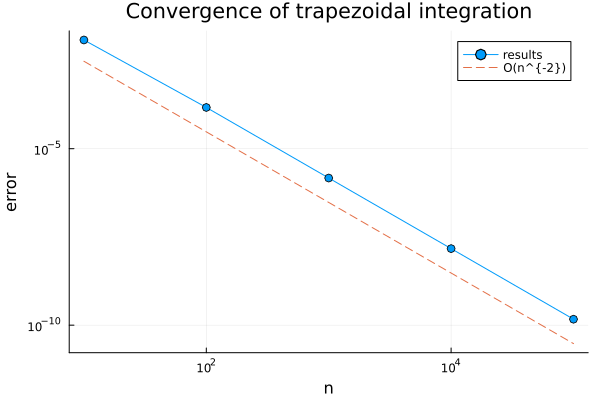

In [20]:
plot(n,abs.(errs),m=:o, label="results",
    xaxis=(:log10,"n"),yaxis=(:log10,"error"),
    title="Convergence of trapezoidal integration")

plot!(n,3e-3*(n/n[1]).^(-2),l=:dash,label="O(n^{-2})")

## Extrapolation

A more careful analysis known as the *Euler-Maclaurin formula* shows that $$I = T_f(n) + c_2 n^{-2} + c_4 n^{-4} + \cdots$$

. . .

and thus, $$I = T_f(2n) + \frac14 c_2 n^{-2} + \frac{1}{16} c_4 n^{-4} + \cdots$$

. . .

Combining $T_f(n)$ and $T_f(2n)$ correctly cancels out the second-order error terms, producing **Simpon's formula**
$$S_f(2n) = \frac13 [4T_f(2n) - T_f(n)].$$

. . .

The truncation error of Simpson's formula is $$I = S_f(2n) + O(n^{-4}).$$

## Node doubling

We can actually do this process again!  A second round of extrapolation leads to $$R_f(4n) = \frac{1}{15}[16S_f(4n) - S_f(2n)].$$  Repeating this extrapolation process recursively is known as **Romberg integration**.

. . .

Note that $R_f(4n)$ depends upon $S_f(2n)$ and $S_f(4n)$, which in turn depend upon $T_f(n), T_f(2n)$, and $T_f(4n)$.  When doubling $n$, only about half of the nodes are new, allowing us to reuse the previously computed function values at the old nodes.

. . .

We have $$T_f(2m) = \frac12 T_f(m) + \frac{1}{2m} \sum_{k=1}^{m} f(t_{2k -1}).$$

# Adaptive integration

We have only used equally spaced nodes to compute integrals, but this may not be ideal.

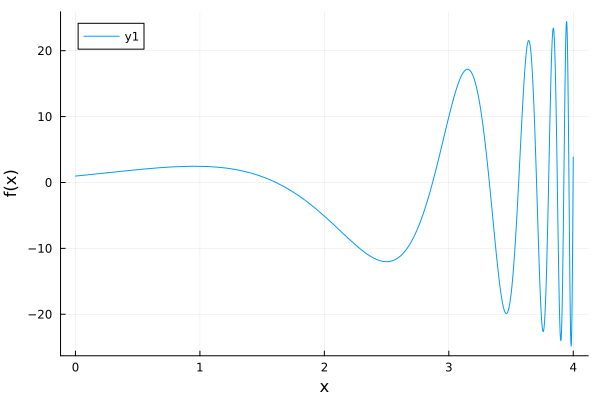

In [22]:
f = x -> (x+1)^2*cos((2*x+1)/(x-4.3))
plot(f,0,4,xlabel="x",ylabel="f(x)")

. . .

Algorithms that automatically detect and react to this kind of situation are **adaptive**.

## Error estimation

$R_f(4n)$ is more accurate than $S_f(4n)$, thus a decent estimate of the error in $S_f(4n)$ is $$I - S_f(4n) \approx E := R_f(4n) - S_f(4n) = \frac{S_f(4n) - S_f(2n)}{15}.$$

. . .

We can calculate $E$!  If in some region, $E$ is acceptably small, we are done and can focus additional nodes in other regions of the integral interval.

. . .

We check a combination of absolute error and relative error to decide when we are done.  

## Divide and conquer

We check if $$|E| < \delta_a + \delta_r |S_f(n)|,$$ where $\delta_a$ and $\delta_r$ are given absolute and relative error tolerances.

. . .

When $E$ fails to meet the bound above, we bisect the interval $[a,b]$ and independently compute estimates of integrals on either half and makes further bisections as necessary.  

---

In [32]:
"""
    intadapt(f,a,b,tol)

Adaptively integrate 'f' over ['a','b'] to within target error tolerance
'tol'.  Returns teh estimate and a vector of evaluation nodes.
"""
function intadapt(f,a,b,tol,fa=f(a),fb=f(b),m=(a+b)/2,fm=f(m))
    # Use error estimation and recursive bisection.
    # These are the two new nodes and their f-values.
    xl = (a+m)/2; fl = f(xl);
    xr = (m+b)/2; fr = f(xr);

    # Compute the trapezoid values iteratively.
    h = (b-a)
    T = [0.,0.,0.]
    T[1] = h*(fa+fb)/2
    T[2] = T[1]/2 + (h/2)*fm
    T[3] = T[2]/2 + (h/4)*(fl+fr)

    S = (4T[2:3] - T[1:2]) / 3         # Simpson values
    E = (S[2] - S[1]) / 15             # error estimate

    if abs(E) < tol*(1 + abs(S[2]))    # acceptable error?
        Q = S[2]                       # yes -- done
        nodes = [a,xl,m,xr,b]          # all nodes at this level
    else
        # Error is too large -- bisect and recurse.
        QL,tL = intadapt(f,a,m,tol,fa,fm,xl,fl)
        QR,tR = intadapt(f,m,b,tol,fm,fb,xr,fr)
        Q = QL + QR
        nodes = [tL;tR[2:end]]         # merge the nodes w/o duplicate
    end
    return Q,nodes
end

intadapt

---

num_nodes = length(t) = 69


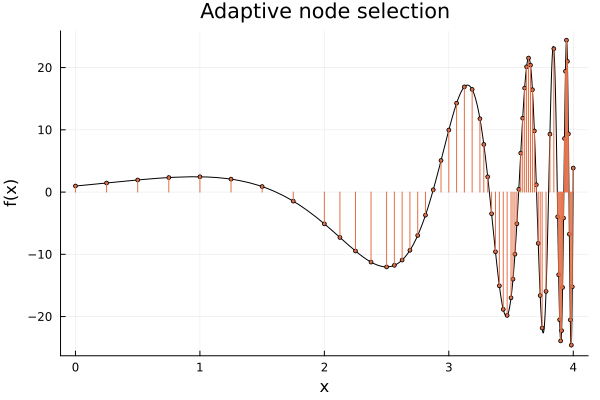

In [33]:
A,t = intadapt(f,0,4,0.001)
@show num_nodes = length(t);

plot(f,0,4,color=:black,legend=:none,
    xlabel="x",ylabel="f(x)",title="Adaptive node selection")
plot!(t,f.(t),seriestype=:sticks,m=(:o,2))

. . .

The error tolerance is not guaranteed to be a bound.  The error estimates are only estimates, not guarantees.

In [34]:
Q,_ = quadgk(f,0,4,atol=1e-14,rtol=1e-14);
println("error: $(Q-A)");

error: -0.022002813037627522


---

In [36]:
tol = [ 1/10^k for k in 4:14 ]
errs,n = [],[]
for tol in 10.0.^(-4:-1:-14)
    A,t = intadapt(f,0,4,tol)
    push!(errs,Q-A)
    push!(n,length(t))
end

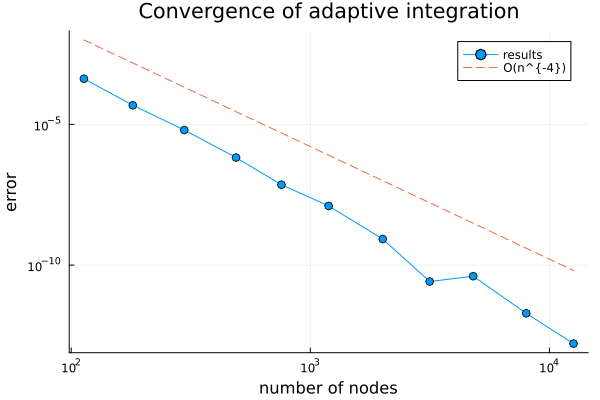

In [37]:
plot(n,abs.(errs),m=:o,label="results",
    xaxis=(:log10,"number of nodes"),yaxis=(:log10,"error"),
    title="Convergence of adaptive integration")
order4 = @. 0.01*(n/n[1])^(-4)
plot!(n,order4,l=:dash,label="O(n^{-4})")

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->